# CTC Sales Base Model: AutoARIMA

Train the repository's Darts AutoARIMA model on the CTC sales training split and forecast the held-out test split.

## 1. Imports and configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from darts import TimeSeries
from darts.models import AutoARIMA

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "CTC":
    CTC_ROOT = REPO_ROOT
else:
    CTC_ROOT = REPO_ROOT / "implementations" / "CTC"

PROCESSED_ROOT = CTC_ROOT / "data" / "processed"
TRAIN_PATH = PROCESSED_ROOT / "ctc_train.parquet"
TEST_PATH = PROCESSED_ROOT / "ctc_test.parquet"
NUM_SAMPLES = 500
FREQUENCY = "W-MON"

print(f"Training data: {TRAIN_PATH}")
print(f"Test data:     {TEST_PATH}")

Training data: /home/coder/agentic-forecasting/implementations/CTC/data/processed/ctc_train.parquet
Test data:     /home/coder/agentic-forecasting/implementations/CTC/data/processed/ctc_test.parquet


## 2. Load and validate the CTC train/test data

In [2]:
train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

required_columns = {"timestamp", "value"}
for name, frame in {"train": train_df, "test": test_df}.items():
    missing = required_columns.difference(frame.columns)
    if missing:
        raise ValueError(f"{name} data is missing columns: {sorted(missing)}")

    frame["timestamp"] = pd.to_datetime(frame["timestamp"], utc=True)
    frame["value"] = pd.to_numeric(frame["value"], errors="raise")

train_df = train_df.sort_values("timestamp").reset_index(drop=True)
test_df = test_df.sort_values("timestamp").reset_index(drop=True)

print(f"Train rows: {len(train_df)} ({train_df.timestamp.min()} to {train_df.timestamp.max()})")
print(f"Test rows:  {len(test_df)} ({test_df.timestamp.min()} to {test_df.timestamp.max()})")
display(train_df.head())
display(test_df.head())

Train rows: 191 (2020-01-06 00:00:00+00:00 to 2023-08-28 00:00:00+00:00)
Test rows:  42 (2024-06-17 00:00:00+00:00 to 2025-03-31 00:00:00+00:00)


,timestamp,value,released_at,timestamp_year,timestamp_month,timestamp_day,timestamp_day_of_week
0,2020-01-06 00:00:00+00:00,143,2020-01-12 00:00:00+00:00,2020,1,6,0
1,2020-01-13 00:00:00+00:00,174,2020-01-19 00:00:00+00:00,2020,1,13,0
2,2020-01-20 00:00:00+00:00,148,2020-01-26 00:00:00+00:00,2020,1,20,0
3,2020-01-27 00:00:00+00:00,141,2020-02-02 00:00:00+00:00,2020,1,27,0
4,2020-02-03 00:00:00+00:00,156,2020-02-09 00:00:00+00:00,2020,2,3,0


,timestamp,value,released_at,timestamp_year,timestamp_month,timestamp_day,timestamp_day_of_week
0,2024-06-17 00:00:00+00:00,124,2024-06-23 00:00:00+00:00,2024,6,17,0
1,2024-06-24 00:00:00+00:00,163,2024-06-30 00:00:00+00:00,2024,6,24,0
2,2024-07-01 00:00:00+00:00,160,2024-07-07 00:00:00+00:00,2024,7,1,0
3,2024-07-08 00:00:00+00:00,143,2024-07-14 00:00:00+00:00,2024,7,8,0
4,2024-07-15 00:00:00+00:00,157,2024-07-21 00:00:00+00:00,2024,7,15,0


## 3. Convert the data to Darts time series

In [4]:
train_series = TimeSeries.from_dataframe(
    train_df,
    time_col="timestamp",
    value_cols="value",
    fill_missing_dates=True,
    freq=FREQUENCY,
)

test_series = TimeSeries.from_dataframe(
    test_df,
    time_col="timestamp",
    value_cols="value",
    fill_missing_dates=True,
    freq=FREQUENCY,
)

print(f"Train series length: {len(train_series)}")
print(f"Test series length:  {len(test_series)}")

The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.
The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.


Train series length: 191
Test series length:  42


## 4. Train AutoARIMA and forecast the test horizon

In [6]:
model = AutoARIMA()
model.fit(train_series)

# The train and test splits are separated by 42 weekly steps.
train_end = train_df["timestamp"].max()
test_start = test_df["timestamp"].min()
gap_steps = (test_start - train_end).days // 7
forecast_horizon = gap_steps + len(test_series)

full_forecast = model.predict(
    n=forecast_horizon,
    num_samples=NUM_SAMPLES,
)

# Keep only the forecast dates covered by the test set.
forecast = full_forecast.slice_intersect(test_series)

if len(forecast) != len(test_series):
    raise ValueError(
        f"Expected {len(test_series)} test forecasts, got {len(forecast)}."
    )

print(f"Gap steps: {gap_steps}")
print(f"Forecast steps through test set: {forecast_horizon}")
forecast_df = pd.DataFrame(
    {
        "timestamp": forecast.time_index,
        "forecast": forecast.values(copy=False).reshape(-1),
    }
)

display(forecast_df.head())

Gap steps: 42
Forecast steps through test set: 84


,timestamp,forecast
0,2024-06-17,160.839980
1,2024-06-24,176.855728
2,2024-07-01,149.406028
3,2024-07-08,134.859043
4,2024-07-15,138.653818


## 5. Evaluate the test forecast

In [7]:
actual = test_df["value"].to_numpy(dtype=float)
predicted = forecast.values(copy=False).reshape(-1)

if len(actual) != len(predicted):
    raise ValueError("The forecast and test set have different lengths.")

errors = predicted - actual
mae = np.mean(np.abs(errors))
rmse = np.sqrt(np.mean(errors**2))
nonzero_actual = actual != 0
mape = np.mean(np.abs(errors[nonzero_actual] / actual[nonzero_actual])) * 100

metrics = pd.Series(
    {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape},
    name="AutoARIMA test metrics",
)
display(metrics.to_frame())

,AutoARIMA test metrics
MAE,13.421064
RMSE,17.274804
MAPE (%),9.139481


## 6. Plot actual values and the AutoARIMA forecast

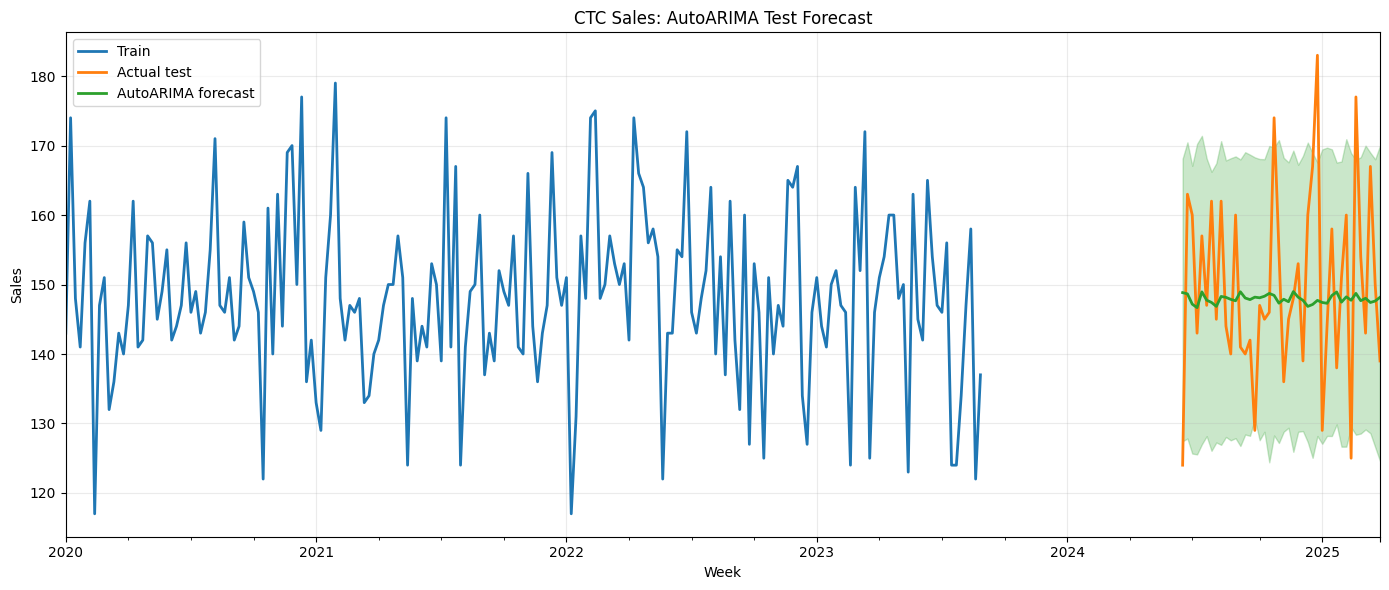

In [8]:
plt.figure(figsize=(14, 6))
train_series.plot(label="Train")
test_series.plot(label="Actual test")
forecast.plot(label="AutoARIMA forecast", low_quantile=0.05, high_quantile=0.95)
plt.title("CTC Sales: AutoARIMA Test Forecast")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Repository model reference

The reusable repository wrapper is `DartsAutoARIMAPredictor` in `aieng-forecasting/aieng/forecasting/methods/numerical/darts_arima.py`. This notebook calls Darts `AutoARIMA` directly so the train/test split and evaluation metrics remain explicit. The wrapper uses the same AutoARIMA backend and fits automatically inside its `predict()` method when used with the repository evaluation framework.